# Variable selection

Hyperspectral data often contains hundreds of spectral bands. While rich in information, using all bands can lead to overfitting, long processing times, and poor generalization to new data. In this notebook, we'll explore how to select informative variables (bands) to build better predictive models using a method called COVSEL (Covariance Selection).

## Loading the data

In [2]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]

X = kiwi_spectra
y = reference_values

# Kennard stone partition data

In [3]:
import kennard_stone as ks

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(kiwi_spectra, reference_values, test_size = 0.2, random_state=1)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-29 15:08:00,072 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-29 15:08:00,075 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

## Variable selection (COVSEL)

COVSEL selects variables (spectral bands) that best explain the response variable, using a leave-one-out cross-validation (LOO) strategy. It builds latent variables step by step, picking at each step the spectral variable that maximizes the covariance with the response.

### Key outputs:

vars: the most informative spectral bands,

RMSECV: how prediction error changes as more variables are added,

Ypreds: predicted values during cross-validation.

In [4]:
import numpy as np
from scipy import stats

def fcovsel_loo(X, y, A):
    """
    Parameters:
    X : numpy array of shape (n, p) - predictor matrix
    y : numpy array of shape (n, m) - response matrix  
    A : int - number of components
    
    Returns:
    RMSECV : list of arrays - RMSE for cross-validation for each response
    Ypreds : list of arrays - predictions for each response
    vars : array - selected variables
    """
    
    n = X.shape[0]
    vars_all = np.zeros((n, A), dtype=int)
    Xc = (np.sum(X, axis=0) - X) / (n - 1)  # Means without i-th sample
    yO = y.copy() 
    
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    
    T = np.zeros((n, A))
    q = np.zeros((y.shape[1], A))
    yc = (np.sum(y, axis=0) - y) / (n - 1)
    
    Ypreds = [np.zeros((n, A + 1)) for _ in range(y.shape[1])]
    n2 = np.zeros(n, dtype=bool)
    
    for i in range(n):
        inds2 = n2.copy()
        inds2[i] = True
        y_temp = yO - yc[i]
        X_temp = X.copy()
        X_temp = X_temp - Xc[i, :]
        X_temp_v = X_temp[i, :].copy()
        X_temp[inds2, :] = 0
        
        W = np.zeros((X.shape[1], A))
        
        for a in range(A):
            v = np.sum((X_temp.T @ y_temp) ** 2, axis=1)
            ind = np.argmax(v)
            vars_all[i, a] = ind
            
            W[ind, a] = 1
            t = X_temp @ W[:, a]
            
            if a > 0:
                t = t - T[:, :a] @ (T[:, :a].T @ t)
            
            t_norm = np.linalg.norm(t)
            if t_norm > 1e-12: #to avoid division by 0
                t = t / t_norm
            T[:, a] = t
            
            # Deflate y
            q[:, a] = y_temp.T @ t
            y_temp = y_temp - np.outer(t, t.T @ y_temp)
        
        # Calculate predictions
        for j in range(q.shape[0]):
            M = (X_temp.T @ T).T @ W
            M_upper = np.triu(M)
            R = W @ np.linalg.inv(M_upper)
            R_scaled = R * q[j, :].reshape(1, -1)
            beta = np.cumsum(R_scaled, axis=1)
            Ypreds[j][i, 1:] = X_temp_v @ beta
    
    # Get mode of selected variables across all iterations
    vars_final = stats.mode(vars_all, axis=0, keepdims=False)[0]
    
    RMSECV = []
    for j in range(len(Ypreds)):
        Ypreds[j] = Ypreds[j] + yc[:, j:j+1]
        if yO.ndim == 1:
            rmsecv = np.sqrt(np.mean((yO - Ypreds[j][:, 1:]) ** 2, axis=0))
        else:
            rmsecv = np.sqrt(np.mean((yO[:, j:j+1] - Ypreds[j][:, 1:]) ** 2, axis=0))
        RMSECV.append(rmsecv)
    
    return RMSECV, Ypreds, vars_final

Let's apply this on our kiwi dataset:

In [5]:
y = np.expand_dims(reference_values, axis=1)
RMSECV, Ypreds, vars = fcovsel_loo(X, y, 50)

print("RMSECV:", RMSECV)
print("Ypreds:", Ypreds)
print("vars:", vars)

RMSECV: [array([1.70993218, 1.34824681, 1.32503239, 1.17492122, 1.15660558,
       1.12489891, 1.00189247, 0.97095465, 0.96201448, 0.90056199,
       0.88617422, 0.87029659, 0.77715924, 0.77698996, 0.73490594,
       0.71073341, 0.703871  , 0.69560667, 0.67851188, 0.68510168,
       0.66340941, 0.6365256 , 0.64872662, 0.63823905, 0.61782832,
       0.61610365, 0.61948159, 0.61822342, 0.61115178, 0.62037902,
       0.63215229, 0.63143011, 0.63929481, 0.63952239, 0.63778642,
       0.66138198, 0.66454784, 0.66163311, 0.65008547, 0.63299906,
       0.6301446 , 0.64963742, 0.63562411, 0.62155177, 0.61146062,
       0.62497119, 0.63392771, 0.63361256, 0.62844626, 0.62548434])]
Ypreds: [array([[17.0010838 , 17.52303608, 16.14013345, ..., 15.43581569,
        15.39912994, 15.38418209],
       [16.99624022, 17.02621989, 17.02424866, ..., 15.12476056,
        15.16364041, 15.18182374],
       [17.00187151, 16.8409924 , 15.99074164, ..., 15.18007352,
        15.16787361, 15.11091452],
       ...

By plotting the LOO RMSE as a function of the number of selected variables, we can find a good trade-off between complexity and performance. Lower RMSE with fewer variables suggests a more efficient model.

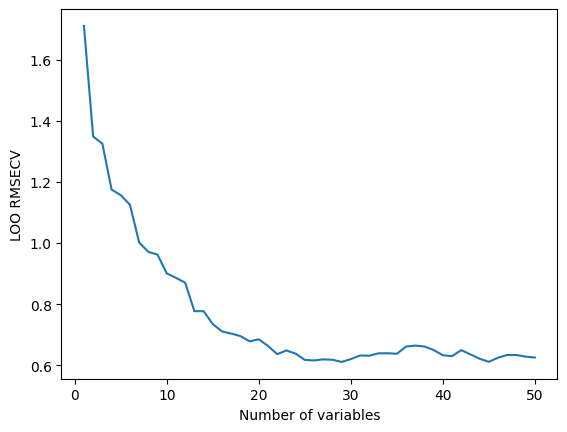

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1, 51),RMSECV[0])
plt.ylabel("LOO RMSECV")
plt.xlabel("Number of variables")
plt.show()

We can see the "elbow" of the plot happing at around 23 variables. In our future training of a calibration model we can just use those 23 wavelengths.

Let's visualize the selected bands

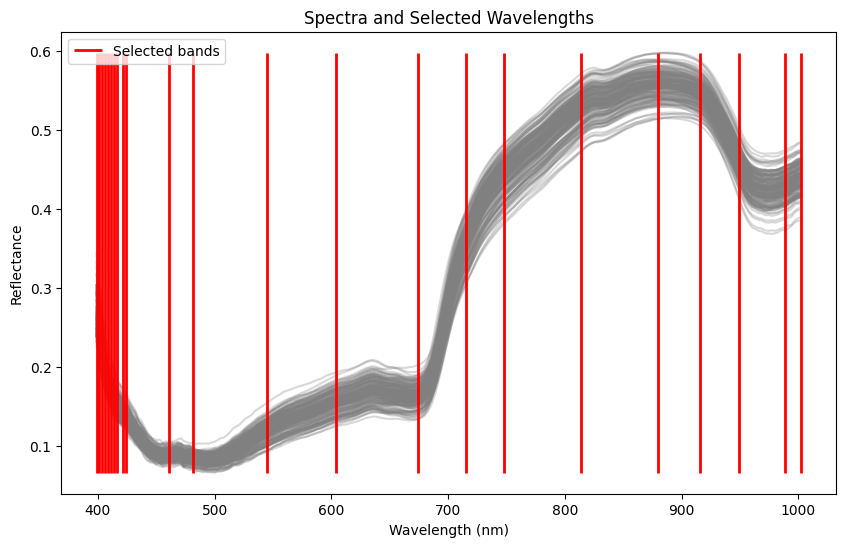

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(wl, kiwi_spectra.T, color='gray', alpha=0.3)
plt.vlines(wl[vars[:23]], ymin=np.min(kiwi_spectra), ymax=np.max(kiwi_spectra), color='red', label='Selected bands', linewidth=2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectra and Selected Wavelengths")
plt.legend()
plt.show()

## Predictive model based on selected variables

We train and test Partial Least Squares (PLS) models using:

- All spectral bands (full model),

- Only selected bands (reduced model).

By comparing prediction quality (R², RMSE) on both calibration and test sets, we can see the impact of variable selection. The reduced model often performs similarly—or even better—while being simpler and faster.

Results of normal PLS


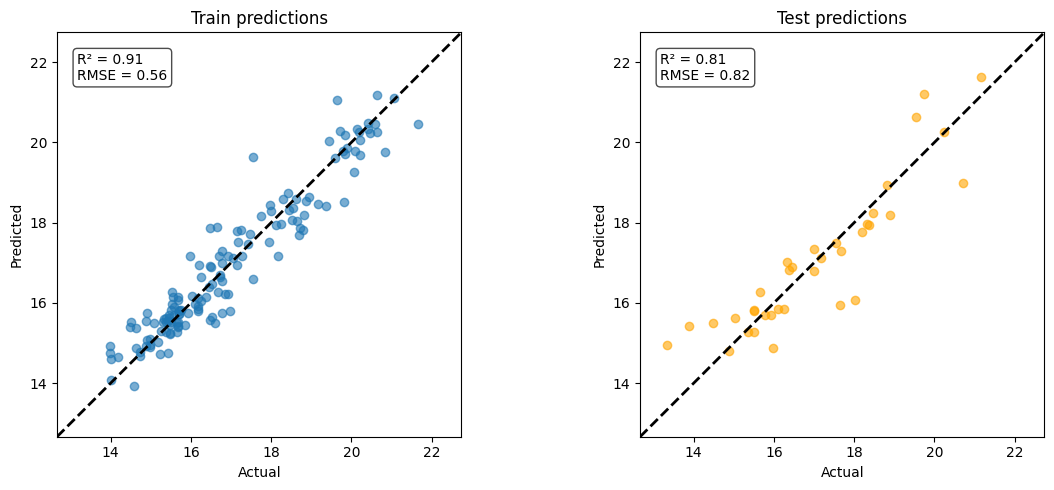

In [7]:
from sklearn.cross_decomposition import PLSRegression
from helperfunctions.plot_functions import plot_cv_vs_test

pls = PLSRegression(n_components=11)
pls.fit(X_cal_ks,y_cal_ks)
y_pred_pls_cv = pls.predict(X_cal_ks)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test, plot_titles=["Train predictions", "Test predictions"])


In [8]:
X_cal_reduced = X_cal_ks[:, vars[:23]]
X_test_reduced = X_test_ks[:, vars[:23]]

Models with fewer components usually are less biased, so on unseen data they perform better.

Even after selecting variables, we must choose how many PLS components to use. Too few and we miss patterns; too many and we overfit. We use cross-validation and test error curves to find the number of components that best balance bias and variance.

4.8% completed

100.0% completed
Suggested number of components: 21


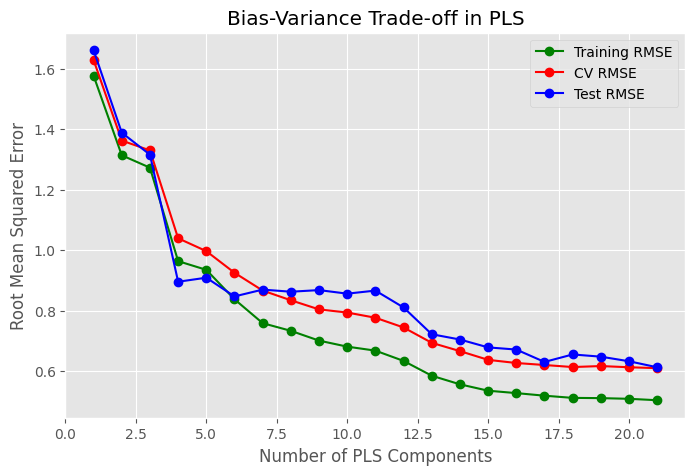

In [9]:
from helperfunctions.optimize import optimise_pls_cv_test
opt_n_comp = optimise_pls_cv_test(X_cal_reduced, y_cal_ks, X_test_reduced, y_test_ks, n_comp=21)

In [10]:
opt_n_comp = 15

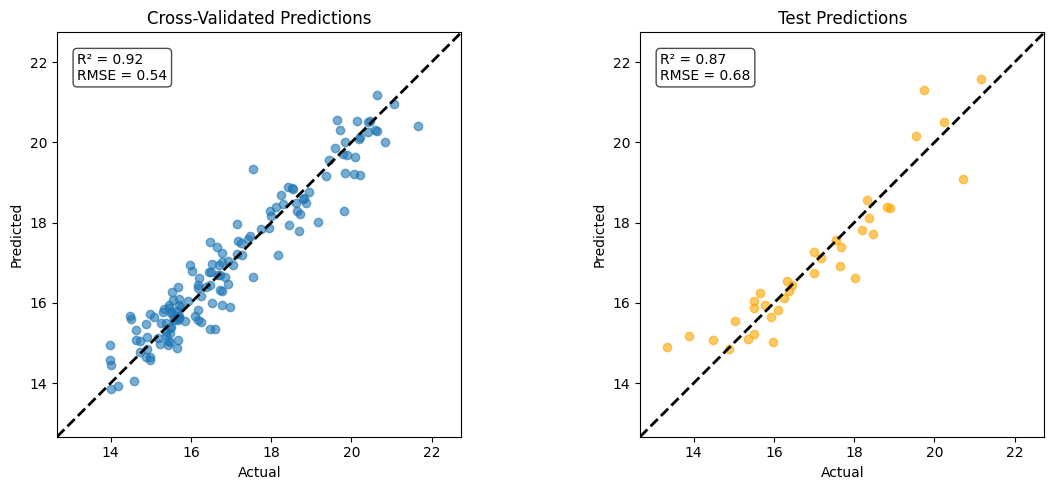

In [11]:
pls = PLSRegression(n_components=opt_n_comp)
pls.fit(X_cal_reduced, y_cal_ks)
y_pred_pls_cv = pls.predict(X_cal_reduced)
y_pred_pls_test = pls.predict(X_test_reduced)
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test)